# Coordinate Geometry

## Contents
1. [The Cartesian Plane](#1.-The-Cartesian-Plane)
2. [Distance, Section Formula and Area](#2.-Distance,-Section-Formula-and-Area)
3. [Locus](#3.-Locus)
4. [Slope of a Line](#4.-Slope-of-a-Line)
5. [Equations of a Straight Line](#5.-Equations-of-a-Straight-Line)
6. [Distances, Foot of Perpendicular and Image](#6.-Distances,-Foot-of-Perpendicular-and-Image)
7. [Pairs and Families of Lines](#7.-Pairs-and-Families-of-Lines)
8. [The Circle](#8.-The-Circle)
9. [Lines and Circles: Tangents](#9.-Lines-and-Circles:-Tangents)
10. [Conic Sections: Focus–Directrix Definition](#10.-Conic-Sections:-Focus–Directrix-Definition)
11. [Parabola](#11.-Parabola)
12. [Ellipse](#12.-Ellipse)
13. [Hyperbola](#13.-Hyperbola)
14. [Identifying a Conic and Shifting the Origin](#14.-Identifying-a-Conic-and-Shifting-the-Origin)
15. [Polar Coordinates](#15.-Polar-Coordinates)
16. [Common Mistakes](#16.-Common-Mistakes)
17. [Formula Sheet](#17.-Formula-Sheet)
18. [Practice Problems (with Answers)](#18.-Practice-Problems-(with-Answers))

Related notebooks: `triangles.ipynb` (centroid, incentre, circumcentre in coordinates) and `algebra.ipynb` (slope and forms of a line, briefly). The code cells use SymPy for exact answers and Matplotlib for figures.

In [1]:
import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x, y, t, k, lam = sp.symbols("x y t k lambda", real=True)
P = sp.Point

def eq(expr):
    """Write a line/curve equation with coprime integer coefficients and a positive leading term."""
    num, _ = sp.fraction(sp.together(sp.expand(expr)))
    poly = sp.Poly(num, x, y)
    _, prim = poly.primitive()
    if prim.LC() < 0:
        prim = -prim
    return f"{prim.as_expr()} = 0"

def circle_from_general(expr):
    """Centre and radius of x² + y² + 2gx + 2fy + c = 0."""
    poly = sp.Poly(sp.expand(expr), x, y)
    g, f, c = poly.coeff_monomial(x) / 2, poly.coeff_monomial(y) / 2, poly.coeff_monomial(1)
    return P(-g, -f), sp.sqrt(g**2 + f**2 - c)

def axes_setup(ax, lim=None):
    ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
    ax.grid(alpha=0.3); ax.set_aspect("equal")
    if lim:
        ax.set_xlim(*lim[:2]); ax.set_ylim(*lim[2:])

print("Ready.")

Ready.


## 1. The Cartesian Plane

Two perpendicular number lines — the $x$-axis (horizontal) and $y$-axis (vertical) — meet at the **origin** $O(0, 0)$. Every point is an ordered pair $(x, y)$: $x$ is the **abscissa**, $y$ the **ordinate**.

| Quadrant | Signs | Example |
|----------|-------|---------|
| I | $(+, +)$ | $(3, 2)$ |
| II | $(-, +)$ | $(-3, 2)$ |
| III | $(-, -)$ | $(-3, -2)$ |
| IV | $(+, -)$ | $(3, -2)$ |

- Points on the $x$-axis have $y = 0$; points on the $y$-axis have $x = 0$.
- Reflection of $(x, y)$ in the $x$-axis: $(x, -y)$; in the $y$-axis: $(-x, y)$; in the origin: $(-x, -y)$; in the line $y = x$: $(y, x)$.

The big idea of coordinate geometry: **turn geometry into algebra.** A curve becomes an equation, and geometric questions (do two lines meet? is a line tangent?) become algebra questions (does a system have a solution? is a discriminant zero?).

## 2. Distance, Section Formula and Area

### Distance formula
$$AB = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$
(Pythagoras on the horizontal and vertical gaps.) Distance from the origin: $\sqrt{x^2 + y^2}$.

**Example.** $(1, 2)$ to $(4, 6)$: $\sqrt{9 + 16} = 5$.

### Section formula
The point dividing $A(x_1, y_1)$ and $B(x_2, y_2)$ in the ratio $m : n$:

| | Point |
|---|---|
| **Internally** | $\left(\dfrac{mx_2 + nx_1}{m + n},\ \dfrac{my_2 + ny_1}{m + n}\right)$ |
| **Externally** | $\left(\dfrac{mx_2 - nx_1}{m - n},\ \dfrac{my_2 - ny_1}{m - n}\right)$ |
| **Midpoint** ($1:1$) | $\left(\dfrac{x_1 + x_2}{2},\ \dfrac{y_1 + y_2}{2}\right)$ |

*Memory aid:* multiply each end by the **opposite** part of the ratio ("cross-multiply").

**Example.** $A(2, 3)$, $B(8, 9)$, ratio $1 : 2$ — internally $(4, 5)$; externally $(-4, -3)$.

**Finding the ratio:** the line $ax + by + c = 0$ divides $AB$ in the ratio $-\dfrac{ax_1 + by_1 + c}{ax_2 + by_2 + c}$ (positive → internal, negative → external).

### Centroid of a triangle
$G = \left(\dfrac{x_1 + x_2 + x_3}{3},\ \dfrac{y_1 + y_2 + y_3}{3}\right)$ (more centres in `triangles.ipynb`).

### Area of a triangle
$$\text{Area} = \frac{1}{2}\left|x_1(y_2 - y_3) + x_2(y_3 - y_1) + x_3(y_1 - y_2)\right| = \frac{1}{2}\left|\det\begin{pmatrix} x_1 & y_1 & 1 \\ x_2 & y_2 & 1 \\ x_3 & y_3 & 1 \end{pmatrix}\right|$$

- **Collinear points** ⇔ area $= 0$.
- Area of a polygon (vertices in order) — **shoelace formula**: $\tfrac{1}{2}\left|\sum (x_iy_{i+1} - x_{i+1}y_i)\right|$.

**Example.** $(1, 1), (4, 2), (2, 5)$: $\tfrac{1}{2}|1(2 - 5) + 4(5 - 1) + 2(1 - 2)| = \tfrac{1}{2}|{-3} + 16 - 2| = 5.5$.

Distance (1,2)-(4,6): 5
Internal 1:2: Point2D(4, 5) | external 1:2: Point2D(-4, -3)
Area of (1,1),(4,2),(2,5): 11/2
(1,2),(3,6),(5,10) collinear? True


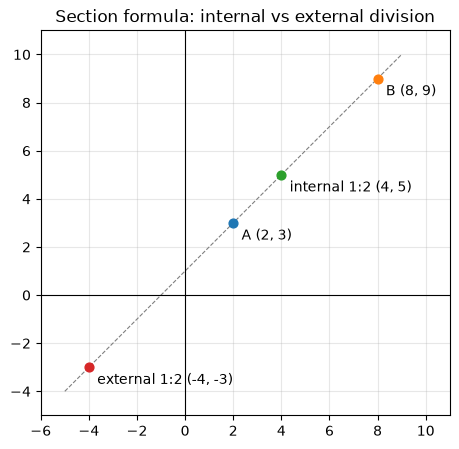

In [2]:
A, B = P(2, 3), P(8, 9)
section = lambda A, B, m, n: P((m*B.x + n*A.x) / (m + n), (m*B.y + n*A.y) / (m + n))
print("Distance (1,2)-(4,6):", P(1, 2).distance(P(4, 6)))
print("Internal 1:2:", section(A, B, 1, 2), "| external 1:2:", section(A, B, 1, -2))
print("Area of (1,1),(4,2),(2,5):", abs(sp.Triangle(P(1, 1), P(4, 2), P(2, 5)).area))
print("(1,2),(3,6),(5,10) collinear?", sp.Point.is_collinear(P(1, 2), P(3, 6), P(5, 10)))

fig, ax = plt.subplots(figsize=(6, 5))
pts = {"A": A, "B": B, "internal 1:2": section(A, B, 1, 2), "external 1:2": section(A, B, 1, -2)}
ax.plot([-5, 9], [-4, 10], color="gray", lw=0.8, ls="--")
for name, p in pts.items():
    ax.scatter(float(p.x), float(p.y), zorder=3, s=40)
    ax.annotate(f"{name} {tuple(int(v) for v in p)}", (float(p.x), float(p.y)), xytext=(6, -12), textcoords="offset points")
axes_setup(ax, (-6, 11, -5, 11)); ax.set_title("Section formula: internal vs external division")
plt.show()

## 3. Locus

A **locus** is the path traced by a point that moves according to a rule. To find its equation:
1. Let the moving point be $P(h, k)$.
2. Write the rule as an equation in $h$ and $k$.
3. Simplify, then replace $h, k$ by $x, y$.

**Example.** Points equidistant from $A(1, 0)$ and $B(-1, 0)$:
$(h - 1)^2 + k^2 = (h + 1)^2 + k^2 \Rightarrow h = 0$ → the **$y$-axis** (the perpendicular bisector of $AB$).

**Example.** Points whose distance from $(2, 0)$ equals their distance from the line $x = -2$:
$(h - 2)^2 + k^2 = (h + 2)^2 \Rightarrow k^2 = 8h$ → the **parabola** $y^2 = 8x$.

**Example.** Points at distance 3 from $(1, 2)$: $(x - 1)^2 + (y - 2)^2 = 9$ → a **circle**.

Every curve in this notebook (line, circle, parabola, ellipse, hyperbola) is a locus.

In [3]:
h, kk = sp.symbols("h k", real=True)
print(sp.expand((h - 1)**2 + kk**2 - ((h + 1)**2 + kk**2)), "= 0")
print(sp.expand((h - 2)**2 + kk**2 - (h + 2)**2), "= 0")

-4*h = 0
-8*h + k**2 = 0


## 4. Slope of a Line

The **slope** (gradient) of a non-vertical line is $m = \tan\theta$, where $\theta$ is the **angle of inclination** with the positive $x$-axis ($0^\circ \le \theta < 180^\circ$).

$$m = \frac{y_2 - y_1}{x_2 - x_1} = \frac{\text{rise}}{\text{run}}, \qquad \text{for } ax + by + c = 0: \ m = -\frac{a}{b}$$

| Line | Slope |
|------|-------|
| Rising (left to right) | $m > 0$ |
| Falling | $m < 0$ |
| Horizontal ($y = k$) | $0$ |
| Vertical ($x = k$) | undefined |

### Parallel and perpendicular
- **Parallel:** $m_1 = m_2$
- **Perpendicular:** $m_1 m_2 = -1$ (or one horizontal and one vertical)

### Angle between two lines
$$\tan\theta = \left|\frac{m_1 - m_2}{1 + m_1m_2}\right|$$
This gives the **acute** angle; the obtuse angle is $180^\circ - \theta$.

**Example.** $y = 2x + 1$ and $y = -3x + 4$: $\tan\theta = \left|\dfrac{2 + 3}{1 - 6}\right| = 1 \Rightarrow \theta = 45^\circ$.

**Collinearity by slopes:** $A, B, C$ are collinear if slope $AB$ = slope $BC$.

## 5. Equations of a Straight Line

| Form | Equation | Use when you know |
|------|----------|-------------------|
| Horizontal / vertical | $y = k$ / $x = k$ | |
| **Point–slope** | $y - y_1 = m(x - x_1)$ | a point and the slope |
| **Slope–intercept** | $y = mx + c$ | slope and $y$-intercept $c$ |
| **Two-point** | $y - y_1 = \dfrac{y_2 - y_1}{x_2 - x_1}(x - x_1)$ | two points |
| **Intercept** | $\dfrac{x}{a} + \dfrac{y}{b} = 1$ | $x$-intercept $a$, $y$-intercept $b$ |
| **Normal** | $x\cos\alpha + y\sin\alpha = p$ | perpendicular distance $p$ from origin, and its direction $\alpha$ |
| **General** | $ax + by + c = 0$ | — every line can be written this way |

### Converting the general form
For $ax + by + c = 0$: slope $-\dfrac{a}{b}$, $x$-intercept $-\dfrac{c}{a}$, $y$-intercept $-\dfrac{c}{b}$.

### Lines parallel / perpendicular to $ax + by + c = 0$
- Parallel: $ax + by + k = 0$ (keep $a, b$, change the constant).
- Perpendicular: $bx - ay + k = 0$ (swap $a, b$ and change one sign).
Find $k$ by substituting the given point.

**Examples**
- Through $(2, 3)$ with slope $-\tfrac{1}{2}$: $y - 3 = -\tfrac{1}{2}(x - 2) \Rightarrow x + 2y - 8 = 0$.
- Intercepts 3 and 4: $\dfrac{x}{3} + \dfrac{y}{4} = 1 \Rightarrow 4x + 3y = 12$.
- Normal form with $p = 5$, $\alpha = 60^\circ$: $\tfrac{1}{2}x + \tfrac{\sqrt{3}}{2}y = 5 \Rightarrow x + \sqrt{3}y = 10$.
- Through $(1, -2)$ parallel to $3x - 4y + 5 = 0$: $3x - 4y - 11 = 0$; perpendicular: $4x + 3y + 2 = 0$.

In [4]:
print(eq(sp.Line(P(2, 3), slope=-sp.Rational(1, 2)).equation(x, y)))
print(eq(sp.Line(P(3, 0), P(0, 4)).equation(x, y)))
L = sp.Line(3*x - 4*y + 5)
print("parallel through (1,-2):", eq(L.parallel_line(P(1, -2)).equation(x, y)))
print("perpendicular through (1,-2):", eq(L.perpendicular_line(P(1, -2)).equation(x, y)))
L1, L2 = sp.Line(P(0, 1), slope=2), sp.Line(P(0, 4), slope=-3)
print("acute angle between y=2x+1 and y=-3x+4:", sp.deg(L1.smallest_angle_between(L2)), "degrees")

x + 2*y - 8 = 0
4*x + 3*y - 12 = 0
parallel through (1,-2): 3*x - 4*y - 11 = 0
perpendicular through (1,-2): 4*x + 3*y + 2 = 0
acute angle between y=2x+1 and y=-3x+4: 45 degrees


## 6. Distances, Foot of Perpendicular and Image

### Distance from a point to a line
$$d = \frac{|ax_1 + by_1 + c|}{\sqrt{a^2 + b^2}}$$
**Example.** $(3, 4)$ to $3x + 4y - 5 = 0$: $\dfrac{|9 + 16 - 5|}{5} = 4$.

### Distance between parallel lines $ax + by + c_1 = 0$ and $ax + by + c_2 = 0$
$$d = \frac{|c_1 - c_2|}{\sqrt{a^2 + b^2}}$$
(Make the $x$ and $y$ coefficients **identical** first.) **Example.** $3x + 4y - 5 = 0$ and $3x + 4y + 10 = 0$: $\tfrac{15}{5} = 3$.

### Foot of the perpendicular and image (reflection)
From $(x_1, y_1)$ to $ax + by + c = 0$:
$$\text{Foot: } \frac{x - x_1}{a} = \frac{y - y_1}{b} = -\frac{ax_1 + by_1 + c}{a^2 + b^2}$$
$$\text{Image: } \frac{x - x_1}{a} = \frac{y - y_1}{b} = -\frac{2(ax_1 + by_1 + c)}{a^2 + b^2}$$

**Example.** From $(3, 4)$ to $x + y - 3 = 0$: $-\dfrac{3 + 4 - 3}{2} = -2$ → foot $(1, 2)$; image $(3 - 4, 4 - 4) = (-1, 0)$.
Check: the midpoint of $(3, 4)$ and $(-1, 0)$ is $(1, 2)$ ✓.

### Same side or opposite sides?
Points $(x_1, y_1)$ and $(x_2, y_2)$ are on the **same side** of $ax + by + c = 0$ if $ax_1 + by_1 + c$ and $ax_2 + by_2 + c$ have the **same sign**.

distance (3,4) to 3x+4y-5=0: 4
parallel lines distance: 3
foot: Point2D(1, 2) | image: Point2D(-1, 0)


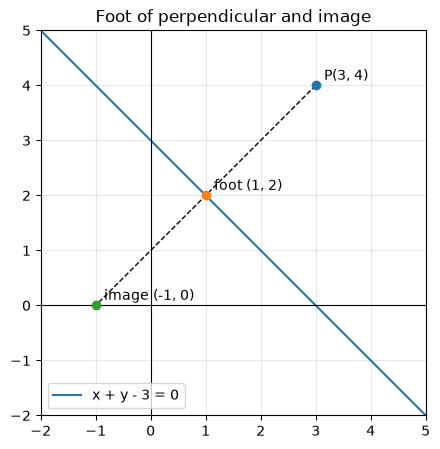

In [5]:
L = sp.Line(x + y - 3)
Q = P(3, 4)
foot = L.projection(Q)
print("distance (3,4) to 3x+4y-5=0:", sp.Line(3*x + 4*y - 5).distance(Q))
print("parallel lines distance:", sp.Line(3*x + 4*y - 5).distance(P(0, sp.Rational(-10, 4))))
print("foot:", foot, "| image:", 2*foot - Q)

fig, ax = plt.subplots(figsize=(5, 5))
xs = np.linspace(-2, 5, 10)
ax.plot(xs, 3 - xs, label="x + y - 3 = 0")
for p, name in [(Q, "P(3, 4)"), (foot, "foot (1, 2)"), (2*foot - Q, "image (-1, 0)")]:
    ax.scatter(float(p.x), float(p.y), zorder=3); ax.annotate(name, (float(p.x), float(p.y)), xytext=(6, 4), textcoords="offset points")
ax.plot([3, -1], [4, 0], "k--", lw=1)
axes_setup(ax, (-2, 5, -2, 5)); ax.legend(loc="lower left"); ax.set_title("Foot of perpendicular and image")
plt.show()

## 7. Pairs and Families of Lines

### Intersection
Solve the two equations simultaneously. $2x + 3y = 13$ and $x - y = -1$ meet at $(2, 3)$.

### Concurrency of three lines
$a_ix + b_iy + c_i = 0$ ($i = 1, 2, 3$) pass through one point if
$$\begin{vmatrix} a_1 & b_1 & c_1 \\ a_2 & b_2 & c_2 \\ a_3 & b_3 & c_3 \end{vmatrix} = 0$$
(or: find the intersection of two and check it lies on the third).

**Example.** $x + y = 3$, $2x - y = 0$, $x - 2y = -3$ all pass through $(1, 2)$.

### Family of lines through an intersection
Every line through the intersection of $L_1 = 0$ and $L_2 = 0$ has the form
$$L_1 + \lambda L_2 = 0$$
Use the extra condition to find $\lambda$ — **no need to find the intersection point**.

**Example.** Line through the intersection of $x + y - 3 = 0$ and $2x - y = 0$, passing through $(2, 5)$:
$(x + y - 3) + \lambda(2x - y) = 0$; at $(2, 5)$: $4 - \lambda = 0 \Rightarrow \lambda = 4$ → $9x - 3y - 3 = 0$, i.e. $3x - y - 1 = 0$.

### Angle bisectors
The bisectors of the angles between $a_1x + b_1y + c_1 = 0$ and $a_2x + b_2y + c_2 = 0$:
$$\frac{a_1x + b_1y + c_1}{\sqrt{a_1^2 + b_1^2}} = \pm\frac{a_2x + b_2y + c_2}{\sqrt{a_2^2 + b_2^2}}$$
(every point on a bisector is equidistant from both lines).

In [6]:
print("intersection:", sp.solve([2*x + 3*y - 13, x - y + 1], [x, y]))
print("concurrency determinant:", sp.Matrix([[1, 1, -3], [2, -1, 0], [1, -2, 3]]).det())
fam = (x + y - 3) + lam*(2*x - y)
lv = sp.solve(fam.subs({x: 2, y: 5}), lam)[0]
print("lambda =", lv, "->", sp.factor(sp.expand(fam.subs(lam, lv))), "= 0")

intersection: {x: 2, y: 3}
concurrency determinant: 0
lambda = 4 -> 3*(3*x - y - 1) = 0


## 8. The Circle

A **circle** is the locus of points at a fixed distance $r$ (radius) from a fixed point (centre).

| Form | Equation | Centre, radius |
|------|----------|----------------|
| Centre at origin | $x^2 + y^2 = r^2$ | $(0, 0)$, $r$ |
| **Standard** | $(x - h)^2 + (y - k)^2 = r^2$ | $(h, k)$, $r$ |
| **General** | $x^2 + y^2 + 2gx + 2fy + c = 0$ | $(-g, -f)$, $\sqrt{g^2 + f^2 - c}$ |
| **Diameter form** (ends $A, B$) | $(x - x_1)(x - x_2) + (y - y_1)(y - y_2) = 0$ | midpoint of $AB$ |
| Parametric | $x = h + r\cos\theta$, $y = k + r\sin\theta$ | |

**Recognising a circle:** coefficients of $x^2$ and $y^2$ are **equal** (divide to make them 1) and there is **no $xy$ term**. It is a real circle only if $g^2 + f^2 - c > 0$ ($= 0$: a point; $< 0$: no real points).

**Examples**
- Centre $(2, -3)$, radius 4: $(x - 2)^2 + (y + 3)^2 = 16 \Rightarrow x^2 + y^2 - 4x + 6y - 3 = 0$.
- $x^2 + y^2 + 4x - 6y - 12 = 0$: $g = 2, f = -3$ → centre $(-2, 3)$, $r = \sqrt{4 + 9 + 12} = 5$.
- Diameter from $(1, 2)$ to $(5, 6)$: $(x - 1)(x - 5) + (y - 2)(y - 6) = 0 \Rightarrow x^2 + y^2 - 6x - 8y + 17 = 0$.
- Circle through three points: substitute into the general form and solve for $g, f, c$ (or find the circumcentre).

### Position of a point
Let $S_1 = x_1^2 + y_1^2 + 2gx_1 + 2fy_1 + c$. The point is **outside** if $S_1 > 0$, **on** if $S_1 = 0$, **inside** if $S_1 < 0$.

In [7]:
c1 = sp.Circle(P(2, -3), 4); print(eq(c1.equation(x, y)))
centre, radius = circle_from_general(x**2 + y**2 + 4*x - 6*y - 12); print("centre", centre, "radius", radius)
c3 = sp.Circle(P(3, 4), P(1, 2).distance(P(3, 4))); print("diameter form:", eq(c3.equation(x, y)))
c4 = sp.Circle(P(0, 0), P(4, 0), P(0, 6)); print("through 3 points:", eq(c4.equation(x, y)))

x**2 - 4*x + y**2 + 6*y - 3 = 0
centre Point2D(-2, 3) radius 5
diameter form: x**2 - 6*x + y**2 - 8*y + 17 = 0
through 3 points: x**2 - 4*x + y**2 - 6*y = 0


## 9. Lines and Circles: Tangents

### Line meets circle
Compare the distance $d$ from the centre to the line with the radius $r$:

| | Intersection |
|---|---|
| $d > r$ | no points |
| $d = r$ | **tangent** (one point) |
| $d < r$ | two points (secant) |

(Equivalently, substitute the line into the circle and look at the discriminant.)

**Condition of tangency** for $y = mx + c$ and $x^2 + y^2 = a^2$: $\;c^2 = a^2(1 + m^2)$.

### Tangent equations
| Circle | Tangent at $(x_1, y_1)$ on the circle |
|--------|-------------------------------------|
| $x^2 + y^2 = a^2$ | $xx_1 + yy_1 = a^2$ |
| $x^2 + y^2 + 2gx + 2fy + c = 0$ | $xx_1 + yy_1 + g(x + x_1) + f(y + y_1) + c = 0$ (written $T = 0$) |

Tangents with slope $m$ to $x^2 + y^2 = a^2$: $\;y = mx \pm a\sqrt{1 + m^2}$.

### Length of the tangent from an external point
$$\text{length} = \sqrt{S_1}$$
**Example.** From $(7, 8)$ to $x^2 + y^2 - 4x - 6y - 12 = 0$: $S_1 = 49 + 64 - 28 - 48 - 12 = 25$ → length $5$.

### Examples
- Tangent to $x^2 + y^2 = 25$ at $(3, 4)$: $3x + 4y = 25$.
- Tangents with slope 2 to $x^2 + y^2 = 9$: $y = 2x \pm 3\sqrt{5}$.
- For which $k$ does $3x + 4y = k$ touch $x^2 + y^2 = 25$? $\dfrac{|k|}{5} = 5 \Rightarrow k = \pm 25$.

### Two circles
With centres $C_1, C_2$ and radii $r_1, r_2$, let $d = C_1C_2$:
$d > r_1 + r_2$ separate · $d = r_1 + r_2$ touch externally · $|r_1 - r_2| < d < r_1 + r_2$ intersect · $d = |r_1 - r_2|$ touch internally · $d < |r_1 - r_2|$ one inside the other.

tangent at (3,4): 3*x + 4*y - 25 = 0


tangents with slope 2 to x²+y²=9: c = [-3*sqrt(5), 3*sqrt(5)]
3x+4y=k tangent: k = [-25, 25]
tangent length from (7,8): 5


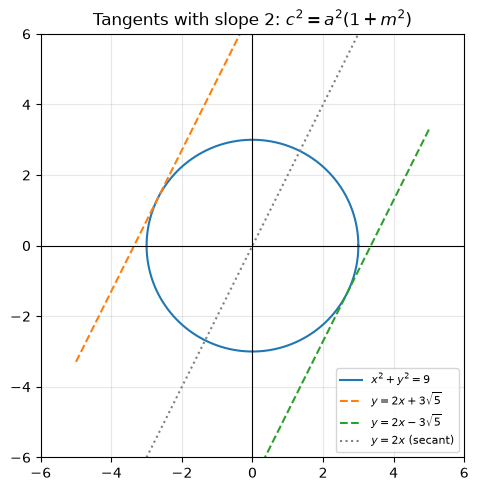

In [8]:
C0 = sp.Circle(P(0, 0), 5)
print("tangent at (3,4):", eq(C0.tangent_lines(P(3, 4))[0].equation(x, y)))
cc = sp.symbols("c", real=True)
print("tangents with slope 2 to x²+y²=9: c =", sp.solve(cc**2 - 9*(1 + 4), cc))
print("3x+4y=k tangent: k =", sp.solve((k/5)**2 - 25, k))
S1 = lambda px, py: px**2 + py**2 - 4*px - 6*py - 12
print("tangent length from (7,8):", sp.sqrt(S1(7, 8)))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
th = np.linspace(0, 2*np.pi, 300)
ax.plot(3*np.cos(th), 3*np.sin(th), label="$x^2 + y^2 = 9$")
xs = np.linspace(-5, 5, 10)
for s in (+1, -1):
    ax.plot(xs, 2*xs + s*3*np.sqrt(5), "--", label=f"$y = 2x {'+' if s > 0 else '-'} 3\\sqrt{{5}}$")
ax.plot(xs, 2*xs, ":", color="gray", label="$y = 2x$ (secant)")
axes_setup(ax, (-6, 6, -6, 6)); ax.legend(fontsize=8, loc="lower right"); ax.set_title("Tangents with slope 2: $c^2 = a^2(1 + m^2)$")
plt.show()

## 10. Conic Sections: Focus–Directrix Definition

A **conic** is the locus of a point $P$ whose distance from a fixed point $S$ (the **focus**) is a constant multiple $e$ of its distance from a fixed line (the **directrix**):
$$\frac{PS}{PM} = e \quad \text{(the eccentricity)}$$

| $e$ | Conic |
|-----|-------|
| $e = 0$ | circle (limiting case) |
| $0 < e < 1$ | **ellipse** |
| $e = 1$ | **parabola** |
| $e > 1$ | **hyperbola** |

They are called *conic sections* because each is the intersection of a plane with a double cone. They appear everywhere in engineering: planetary orbits (ellipses), satellite dishes and headlights (parabolic reflectors), projectile paths (parabolas), cooling towers and navigation systems (hyperbolas).

### Vocabulary
| Term | Meaning |
|------|---------|
| Axis | Line through the focus perpendicular to the directrix (line of symmetry) |
| Vertex | Where the conic meets its axis |
| Latus rectum | Chord through a focus, perpendicular to the axis |
| Focal distance | Distance of a point on the conic from a focus |

## 11. Parabola

Standard form: $\;\boxed{y^2 = 4ax}\;$ ($a > 0$)

| Feature | Value |
|---------|-------|
| Vertex | $(0, 0)$ |
| Focus | $(a, 0)$ |
| Directrix | $x = -a$ |
| Axis | $y = 0$ |
| Latus rectum | length $4a$, ends $(a, \pm 2a)$ |
| Focal distance of $(x, y)$ | $x + a$ |
| Parametric point | $(at^2, 2at)$ |
| Tangent at $(x_1, y_1)$ | $yy_1 = 2a(x + x_1)$ |
| Tangent with slope $m$ | $y = mx + \dfrac{a}{m}$ |

### The four orientations
| Equation | Opens | Focus | Directrix |
|----------|-------|-------|-----------|
| $y^2 = 4ax$ | right | $(a, 0)$ | $x = -a$ |
| $y^2 = -4ax$ | left | $(-a, 0)$ | $x = a$ |
| $x^2 = 4ay$ | up | $(0, a)$ | $y = -a$ |
| $x^2 = -4ay$ | down | $(0, -a)$ | $y = a$ |

Vertex at $(h, k)$: replace $x \to x - h$, $y \to y - k$, e.g. $(y - k)^2 = 4a(x - h)$.

**Examples**
- $y^2 = 12x$: $a = 3$, focus $(3, 0)$, directrix $x = -3$, latus rectum 12. The point $(3, 6)$ is on it and its focal distance is $3 + 3 = 6$.
- $x^2 = -8y$: $a = 2$, opens down, focus $(0, -2)$, directrix $y = 2$.
- $y = x^2 - 4x + 7 = (x - 2)^2 + 3$ → $(x - 2)^2 = y - 3$, vertex $(2, 3)$, $4a = 1$.

**Reflective property:** rays parallel to the axis reflect through the focus — the principle behind dish antennas and torches.

## 12. Ellipse

Standard form: $\;\boxed{\dfrac{x^2}{a^2} + \dfrac{y^2}{b^2} = 1}\;$ with $a > b > 0$ (major axis along $x$)

$$b^2 = a^2(1 - e^2), \qquad c = ae = \sqrt{a^2 - b^2}$$

| Feature | Value |
|---------|-------|
| Centre | $(0, 0)$ |
| Vertices | $(\pm a, 0)$; co-vertices $(0, \pm b)$ |
| Major / minor axis length | $2a$ / $2b$ |
| Foci | $(\pm ae, 0)$ |
| Directrices | $x = \pm\dfrac{a}{e}$ |
| Eccentricity | $e = \sqrt{1 - \dfrac{b^2}{a^2}}$ |
| Latus rectum | $\dfrac{2b^2}{a}$ |
| **Sum of focal distances** | $PS_1 + PS_2 = 2a$ |
| Parametric point | $(a\cos\theta, b\sin\theta)$ |
| Tangent at $(x_1, y_1)$ | $\dfrac{xx_1}{a^2} + \dfrac{yy_1}{b^2} = 1$ |
| Tangent with slope $m$ | $y = mx \pm \sqrt{a^2m^2 + b^2}$ |
| Area | $\pi ab$ |

If $b > a$ the major axis is vertical: foci $(0, \pm be)$, $a^2 = b^2(1 - e^2)$.

**Example.** $\dfrac{x^2}{25} + \dfrac{y^2}{9} = 1$: $a = 5, b = 3$, $e = \sqrt{1 - \tfrac{9}{25}} = \tfrac{4}{5}$, foci $(\pm 4, 0)$, directrices $x = \pm\tfrac{25}{4}$, latus rectum $\tfrac{18}{5}$, and every point has $PS_1 + PS_2 = 10$.

**Example.** Foci $(\pm 3, 0)$, major axis 10: $a = 5$, $c = 3$, $b^2 = 16$ → $\dfrac{x^2}{25} + \dfrac{y^2}{16} = 1$.

**"String method":** pin a loop of string at two foci and trace with a pencil — the constant sum $2a$ draws an ellipse. A circle is an ellipse with $e = 0$ ($a = b$).

## 13. Hyperbola

Standard form: $\;\boxed{\dfrac{x^2}{a^2} - \dfrac{y^2}{b^2} = 1}$

$$b^2 = a^2(e^2 - 1), \qquad c = ae = \sqrt{a^2 + b^2}$$

| Feature | Value |
|---------|-------|
| Centre | $(0, 0)$ |
| Vertices | $(\pm a, 0)$ |
| Transverse / conjugate axis | $2a$ / $2b$ |
| Foci | $(\pm ae, 0)$ |
| Directrices | $x = \pm\dfrac{a}{e}$ |
| Eccentricity | $e = \sqrt{1 + \dfrac{b^2}{a^2}}$ |
| Latus rectum | $\dfrac{2b^2}{a}$ |
| **Difference of focal distances** | $\lvert PS_1 - PS_2\rvert = 2a$ |
| **Asymptotes** | $y = \pm\dfrac{b}{a}x$ |
| Parametric point | $(a\sec\theta, b\tan\theta)$ |
| Tangent at $(x_1, y_1)$ | $\dfrac{xx_1}{a^2} - \dfrac{yy_1}{b^2} = 1$ |
| Tangent with slope $m$ | $y = mx \pm \sqrt{a^2m^2 - b^2}$ |

**Conjugate hyperbola** $\dfrac{y^2}{b^2} - \dfrac{x^2}{a^2} = 1$ opens up/down, with the same asymptotes.

**Rectangular hyperbola** ($a = b$): asymptotes perpendicular, $e = \sqrt{2}$. Rotated by $45^\circ$ it becomes $\boxed{xy = c^2}$ (asymptotes: the axes). $y = \tfrac{1}{x}$ is one.

**Example.** $\dfrac{x^2}{16} - \dfrac{y^2}{9} = 1$: $a = 4, b = 3$, $e = \tfrac{5}{4}$, foci $(\pm 5, 0)$, asymptotes $y = \pm\tfrac{3}{4}x$, latus rectum $\tfrac{9}{2}$.

### Ellipse vs hyperbola at a glance
| | Ellipse | Hyperbola |
|---|---|---|
| Sign between terms | $+$ | $-$ |
| $c^2$ | $a^2 - b^2$ | $a^2 + b^2$ |
| $e$ | $< 1$ | $> 1$ |
| Focal property | sum $= 2a$ | difference $= 2a$ |
| Tangency condition $c^2 =$ | $a^2m^2 + b^2$ | $a^2m^2 - b^2$ |

In [9]:
def conic_info(kind, a, b):
    if kind == "ellipse":
        c = sp.sqrt(a**2 - b**2)
    else:
        c = sp.sqrt(a**2 + b**2)
    e = c / a
    return dict(e=e, foci=(c, -c), directrix=a/e, latus_rectum=2*b**2/a)

print("ellipse x²/25 + y²/9 = 1  :", conic_info("ellipse", 5, 3))
print("hyperbola x²/16 - y²/9 = 1:", conic_info("hyperbola", 4, 3))

# Focal property check on random points
th = np.random.default_rng(1).uniform(0, 2*np.pi, 5)
ex, ey = 5*np.cos(th), 3*np.sin(th)
print("ellipse   PS1 + PS2:", np.round(np.hypot(ex - 4, ey) + np.hypot(ex + 4, ey), 10))
hx, hy = 4/np.cos(th), 3*np.tan(th)
print("hyperbola |PS1 - PS2|:", np.round(np.abs(np.hypot(hx - 5, hy) - np.hypot(hx + 5, hy)), 10))

ellipse x²/25 + y²/9 = 1  : {'e': 4/5, 'foci': (4, -4), 'directrix': 25/4, 'latus_rectum': 3.6}
hyperbola x²/16 - y²/9 = 1: {'e': 5/4, 'foci': (5, -5), 'directrix': 16/5, 'latus_rectum': 4.5}
ellipse   PS1 + PS2: [10. 10. 10. 10. 10.]
hyperbola |PS1 - PS2|: [8. 8. 8. 8. 8.]


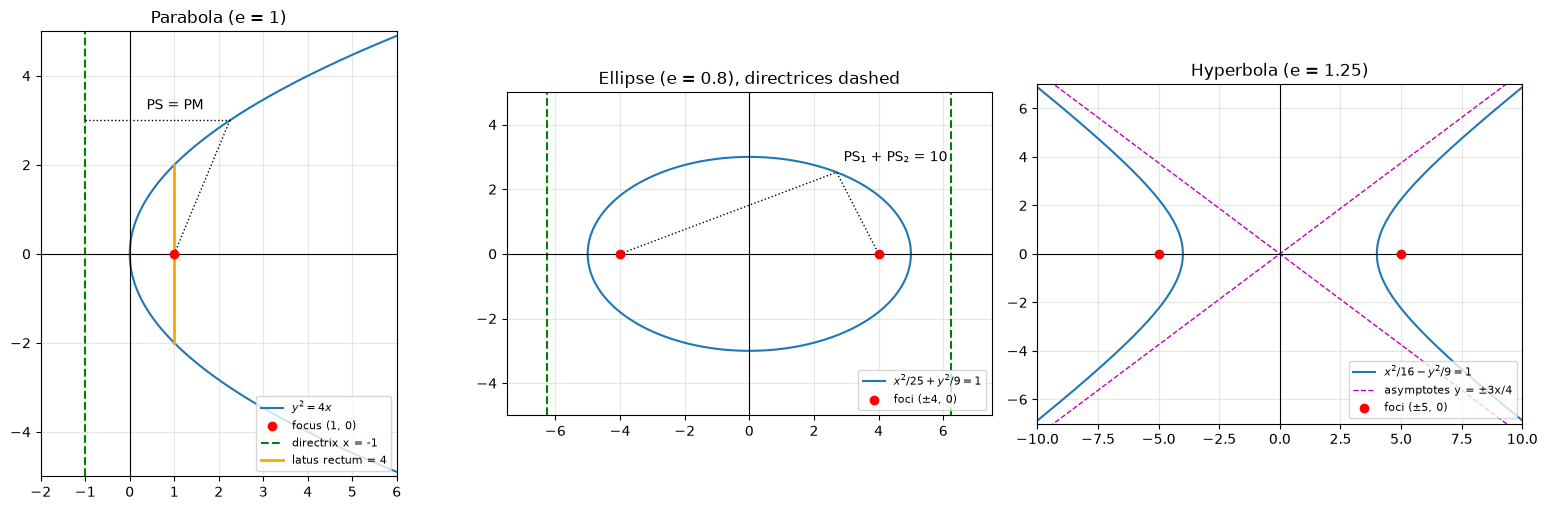

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
# Parabola y^2 = 4ax with a = 1
a = 1; tt = np.linspace(-3, 3, 300); ax = axes[0]
ax.plot(a*tt**2, 2*a*tt, label="$y^2 = 4x$")
ax.scatter([a], [0], color="red", zorder=3, label="focus (1, 0)")
ax.axvline(-a, color="green", ls="--", label="directrix x = -1")
ax.plot([a, a], [-2*a, 2*a], color="orange", lw=2, label="latus rectum = 4")
px, py = a*1.5**2, 2*a*1.5
ax.plot([px, a], [py, 0], "k:", lw=1); ax.plot([px, -a], [py, py], "k:", lw=1)
ax.annotate("PS = PM", (px, py), xytext=(-60, 8), textcoords="offset points")
axes_setup(ax, (-2, 6, -5, 5)); ax.legend(fontsize=8, loc="lower right"); ax.set_title("Parabola (e = 1)")

# Ellipse
A, B = 5, 3; th = np.linspace(0, 2*np.pi, 300); ax = axes[1]
ax.plot(A*np.cos(th), B*np.sin(th), label="$x^2/25 + y^2/9 = 1$")
ax.scatter([4, -4], [0, 0], color="red", zorder=3, label="foci (±4, 0)")
for d in (25/4, -25/4):
    ax.axvline(d, color="green", ls="--")
qx, qy = A*np.cos(1.0), B*np.sin(1.0)
ax.plot([-4, qx, 4], [0, qy, 0], "k:", lw=1); ax.annotate("PS₁ + PS₂ = 10", (qx, qy), xytext=(5, 8), textcoords="offset points")
axes_setup(ax, (-7.5, 7.5, -5, 5)); ax.legend(fontsize=8, loc="lower right"); ax.set_title("Ellipse (e = 0.8), directrices dashed")

# Hyperbola
A, B = 4, 3; u = np.linspace(-2.2, 2.2, 300); ax = axes[2]
for s in (1, -1):
    ax.plot(s*A*np.cosh(u), B*np.sinh(u), color="C0", label="$x^2/16 - y^2/9 = 1$" if s == 1 else None)
xs = np.linspace(-10, 10, 10)
ax.plot(xs, 0.75*xs, "m--", lw=1, label="asymptotes y = ±3x/4"); ax.plot(xs, -0.75*xs, "m--", lw=1)
ax.scatter([5, -5], [0, 0], color="red", zorder=3, label="foci (±5, 0)")
axes_setup(ax, (-10, 10, -7, 7)); ax.legend(fontsize=8, loc="lower right"); ax.set_title("Hyperbola (e = 1.25)")
plt.tight_layout(); plt.show()

## 14. Identifying a Conic and Shifting the Origin

### Completing the square
Group $x$-terms and $y$-terms, complete the square, and compare with a standard form.

**Example.** $9x^2 + 4y^2 - 18x + 16y - 11 = 0$:
$9(x - 1)^2 - 9 + 4(y + 2)^2 - 16 - 11 = 0 \Rightarrow 9(x - 1)^2 + 4(y + 2)^2 = 36 \Rightarrow \dfrac{(x - 1)^2}{4} + \dfrac{(y + 2)^2}{9} = 1$.
An **ellipse** with centre $(1, -2)$, vertical major axis, $a = 3$, $b = 2$.

### Shifting the origin (translation)
Moving the origin to $(h, k)$: $\;x = X + h$, $y = Y + k$. The shape is unchanged; only its equation simplifies. Above, $X = x - 1$, $Y = y + 2$ gives $\tfrac{X^2}{4} + \tfrac{Y^2}{9} = 1$.

### General second-degree equation
$$Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0$$
For a non-degenerate conic, the **discriminant** $B^2 - 4AC$ decides the type:

| $B^2 - 4AC$ | Conic |
|-------------|-------|
| $< 0$ | ellipse (circle if $A = C$ and $B = 0$) |
| $= 0$ | parabola |
| $> 0$ | hyperbola |

The $xy$ term means the axes are **rotated**. Examples: $3x^2 + 2xy + 3y^2 = 8$ → $4 - 36 < 0$, ellipse; $xy = 1$ → $1 > 0$, hyperbola; $x^2 + 2xy + y^2 + x = 0$ → $0$, parabola.

In [11]:
expr = 9*x**2 + 4*y**2 - 18*x + 16*y - 11
X, Y = sp.symbols("X Y")
print("shifted:", sp.expand(expr.subs({x: X + 1, y: Y - 2})), "= 0")
for name, (A_, B_, C_) in {"3x²+2xy+3y²=8": (3, 2, 3), "xy=1": (0, 1, 0), "x²+2xy+y²+x=0": (1, 2, 1)}.items():
    D = B_**2 - 4*A_*C_
    print(f"{name:<18} B²-4AC = {D:>4} ->", "ellipse" if D < 0 else "parabola" if D == 0 else "hyperbola")

shifted: 9*X**2 + 4*Y**2 - 36 = 0
3x²+2xy+3y²=8      B²-4AC =  -32 -> ellipse
xy=1               B²-4AC =    1 -> hyperbola
x²+2xy+y²+x=0      B²-4AC =    0 -> parabola


## 15. Polar Coordinates

A point can also be located by its distance $r$ from the origin and the angle $\theta$ from the positive $x$-axis.

$$x = r\cos\theta, \quad y = r\sin\theta, \qquad r = \sqrt{x^2 + y^2}, \quad \tan\theta = \frac{y}{x}$$

(Choose $\theta$ in the correct quadrant — the same idea as the argument of a complex number in your `complex_number/` notes.)

| Curve | Cartesian | Polar |
|-------|-----------|-------|
| Circle, centre origin | $x^2 + y^2 = a^2$ | $r = a$ |
| Line through origin | $y = x\tan\alpha$ | $\theta = \alpha$ |
| Circle through origin | $x^2 + y^2 = 2ax$ | $r = 2a\cos\theta$ |

### Conics in polar form (focus at the origin)
$$r = \frac{l}{1 + e\cos\theta}$$
where $l$ is the semi-latus rectum. One equation gives **all** conics as $e$ varies — this is how planetary orbits are written.

**Example.** $r = \dfrac{2}{1 + \cos\theta}$ ($e = 1$): $r + x = 2 \Rightarrow x^2 + y^2 = (2 - x)^2 \Rightarrow y^2 = 4 - 4x$, a parabola.

Polar coordinates are used in MIT 18.01 for areas of curves like cardioids $r = 1 + \cos\theta$.

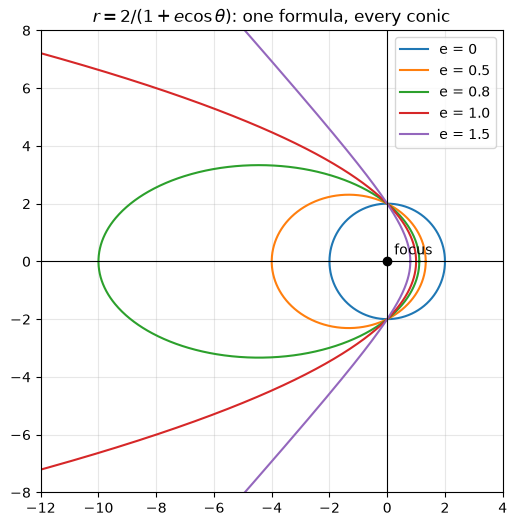

r = 2/(1+cosθ) in Cartesian: -4*x - y**2 + 4 = 0  ->  y² = 4 - 4x


In [12]:
th = np.linspace(0, 2*np.pi, 2000)
fig, ax = plt.subplots(figsize=(6.5, 6))
for e, col in [(0, "C0"), (0.5, "C1"), (0.8, "C2"), (1.0, "C3"), (1.5, "C4")]:
    r = 2 / (1 + e*np.cos(th))
    r[(r < 0) | (r > 30)] = np.nan
    ax.plot(r*np.cos(th), r*np.sin(th), color=col, label=f"e = {e}")
ax.scatter([0], [0], color="black", zorder=3); ax.annotate("focus", (0, 0), xytext=(5, 5), textcoords="offset points")
axes_setup(ax, (-12, 4, -8, 8)); ax.legend(); ax.set_title("$r = 2/(1 + e\\cos\\theta)$: one formula, every conic")
plt.show()

r_, th_ = sp.symbols("r theta")
print("r = 2/(1+cosθ) in Cartesian:", sp.expand((2 - x)**2 - (x**2 + y**2)), "= 0  ->  y² = 4 - 4x")

## 16. Common Mistakes

| Mistake | Correct |
|---------|---------|
| Section formula with the ratio parts on the "wrong" ends | $\dfrac{mx_2 + nx_1}{m + n}$ — $m$ goes with the **far** end $B$ |
| Forgetting the absolute value in area or distance formulas | Area and distance are never negative |
| Distance between parallel lines without matching coefficients | Rewrite so $a, b$ are identical first ($6x + 8y$ vs $3x + 4y$) |
| Slope of $ax + by + c = 0$ taken as $\tfrac{a}{b}$ | It is $-\tfrac{a}{b}$ |
| Perpendicular means $m_1 = -m_2$ | It means $m_1m_2 = -1$ |
| Centre of $x^2 + y^2 + 2gx + 2fy + c = 0$ taken as $(g, f)$ | Centre is $(-g, -f)$; halve the coefficients of $x$ and $y$ first |
| Applying circle formulas when $x^2$ and $y^2$ have different coefficients | Divide so both are 1 — if they can't be made equal, it isn't a circle |
| Mixing up $c^2 = a^2 - b^2$ (ellipse) and $c^2 = a^2 + b^2$ (hyperbola) | Ellipse: foci **inside**; hyperbola: foci **outside** the vertices |
| Assuming the larger denominator is always under $x^2$ | For an ellipse the major axis follows the **larger** denominator |
| Using $y^2 = 4ax$ formulas for $x^2 = 4ay$ | Swap the roles of $x$ and $y$ |
| Forgetting the $\pm$ in tangent-with-slope formulas | There are two parallel tangents |

## 17. Formula Sheet

| Item | Formula |
|------|---------|
| Distance | $\sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$ |
| Section (internal $m:n$) | $\left(\frac{mx_2 + nx_1}{m + n}, \frac{my_2 + ny_1}{m + n}\right)$ |
| Area of triangle | $\tfrac{1}{2}\lvert x_1(y_2 - y_3) + x_2(y_3 - y_1) + x_3(y_1 - y_2)\rvert$ |
| Slope | $\dfrac{y_2 - y_1}{x_2 - x_1} = \tan\theta = -\dfrac{a}{b}$ |
| Angle between lines | $\tan\theta = \left\lvert\dfrac{m_1 - m_2}{1 + m_1m_2}\right\rvert$ |
| Parallel / perpendicular | $m_1 = m_2$ / $m_1m_2 = -1$ |
| Line forms | $y - y_1 = m(x - x_1)$, $y = mx + c$, $\tfrac{x}{a} + \tfrac{y}{b} = 1$, $x\cos\alpha + y\sin\alpha = p$ |
| Point to line | $\dfrac{\lvert ax_1 + by_1 + c\rvert}{\sqrt{a^2 + b^2}}$ |
| Parallel lines | $\dfrac{\lvert c_1 - c_2\rvert}{\sqrt{a^2 + b^2}}$ |
| Family through intersection | $L_1 + \lambda L_2 = 0$ |
| Circle | $(x - h)^2 + (y - k)^2 = r^2$; general: centre $(-g, -f)$, $r = \sqrt{g^2 + f^2 - c}$ |
| Tangent to $x^2 + y^2 = a^2$ | at $(x_1, y_1)$: $xx_1 + yy_1 = a^2$; slope $m$: $y = mx \pm a\sqrt{1 + m^2}$ |
| Tangent length | $\sqrt{S_1}$ |
| Parabola $y^2 = 4ax$ | focus $(a, 0)$, directrix $x = -a$, LR $4a$, $(at^2, 2at)$, tangent $y = mx + \tfrac{a}{m}$ |
| Ellipse $\tfrac{x^2}{a^2} + \tfrac{y^2}{b^2} = 1$ | $b^2 = a^2(1 - e^2)$, foci $(\pm ae, 0)$, LR $\tfrac{2b^2}{a}$, $PS_1 + PS_2 = 2a$ |
| Hyperbola $\tfrac{x^2}{a^2} - \tfrac{y^2}{b^2} = 1$ | $b^2 = a^2(e^2 - 1)$, foci $(\pm ae, 0)$, asymptotes $y = \pm\tfrac{b}{a}x$, $\lvert PS_1 - PS_2\rvert = 2a$ |
| Directrices (ellipse, hyperbola) | $x = \pm\dfrac{a}{e}$ |
| Conic type | $B^2 - 4AC$: $< 0$ ellipse, $= 0$ parabola, $> 0$ hyperbola |
| Polar | $x = r\cos\theta$, $y = r\sin\theta$; conic $r = \dfrac{l}{1 + e\cos\theta}$ |

## 18. Practice Problems (with Answers)

### Level 1 — Basics
1. Find the distance between $(-2, 3)$ and $(4, -5)$.
2. Find the point dividing the join of $(-1, 7)$ and $(4, -3)$ internally in the ratio $2 : 3$.
3. Find the area of the triangle with vertices $(2, 3)$, $(-1, 0)$, $(2, -4)$.
4. Find $k$ if $(k, -1)$, $(2, 1)$, $(4, 5)$ are collinear.
5. Find the equation of the line through $(1, -2)$ parallel to $3x - 4y + 5 = 0$.
6. Find the equation of the line through $(1, -2)$ perpendicular to $3x - 4y + 5 = 0$.
7. Find the acute angle between $y = \sqrt{3}x$ and $y = \tfrac{1}{\sqrt{3}}x$.

### Level 2 — Standard
8. Find the distance of $(2, -1)$ from $4x - 3y + 9 = 0$.
9. Find the distance between the parallel lines $6x + 8y - 15 = 0$ and $3x + 4y + 5 = 0$.
10. Find the image of $(1, 2)$ in the line $x - y + 3 = 0$.
11. Find the centre and radius of $x^2 + y^2 - 6x + 8y = 0$.
12. Find the circle through $(0, 0)$, $(4, 0)$ and $(0, 6)$.
13. Find the tangent to $x^2 + y^2 = 25$ at $(-3, 4)$.
14. For which $k$ does $y = x + k$ touch $x^2 + y^2 = 8$?

### Level 3 — Challenge
15. Find the focus, directrix and latus rectum of $y^2 = -16x$.
16. Find the ellipse with vertices $(\pm 6, 0)$ and foci $(\pm 4, 0)$, and its eccentricity.
17. Find the hyperbola with foci $(0, \pm 13)$ and conjugate axis of length 24.
18. Identify the conic $9x^2 + 4y^2 - 18x + 16y - 11 = 0$ and find its centre.
19. Find the locus of a point equidistant from $(0, 3)$ and the line $y = -3$.
20. Find the points on $y^2 = 8x$ whose focal distance is 6.

<details>
<summary><strong>Answers</strong> (click to expand)</summary>

1. $\sqrt{36 + 64} = 10$
2. $\left(\tfrac{8 - 3}{5}, \tfrac{-6 + 21}{5}\right) = (1, 3)$
3. $\tfrac{1}{2}\lvert 2(4) - 1(-7) + 2(3)\rvert = 10.5$
4. $-4k + 12 - 8 = 0 \Rightarrow k = 1$
5. $3x - 4y - 11 = 0$
6. $4x + 3y + 2 = 0$
7. $\tan\theta = \dfrac{\sqrt{3} - 1/\sqrt{3}}{1 + 1} = \dfrac{1}{\sqrt{3}} \Rightarrow 30^\circ$
8. $\dfrac{\lvert 8 + 3 + 9\rvert}{5} = 4$
9. Write the second as $6x + 8y + 10 = 0$: $\dfrac{25}{10} = 2.5$
10. $(-1, 4)$
11. Centre $(3, -4)$, radius 5
12. Right angle at the origin → diameter from $(4, 0)$ to $(0, 6)$: $x^2 + y^2 - 4x - 6y = 0$
13. $-3x + 4y = 25$
14. $k^2 = 8(1 + 1) \Rightarrow k = \pm 4$
15. $a = 4$, opens left: focus $(-4, 0)$, directrix $x = 4$, latus rectum 16
16. $a = 6$, $c = 4$, $b^2 = 20$: $\dfrac{x^2}{36} + \dfrac{y^2}{20} = 1$, $e = \tfrac{2}{3}$
17. Vertical: $c = 13$, $b = 12$, $a^2 = 25$: $\dfrac{y^2}{25} - \dfrac{x^2}{144} = 1$
18. $\dfrac{(x - 1)^2}{4} + \dfrac{(y + 2)^2}{9} = 1$: ellipse, centre $(1, -2)$, vertical major axis
19. $x^2 + (y - 3)^2 = (y + 3)^2 \Rightarrow x^2 = 12y$
20. $x + 2 = 6 \Rightarrow x = 4$, $y^2 = 32$: $(4, \pm 4\sqrt{2})$

</details>

In [13]:
# Check the practice answers with SymPy
print(" 1.", P(-2, 3).distance(P(4, -5)))
print(" 2.", section(P(-1, 7), P(4, -3), 2, 3))
print(" 3.", abs(sp.Triangle(P(2, 3), P(-1, 0), P(2, -4)).area))
print(" 4.", sp.solve(sp.Matrix([[k, -1, 1], [2, 1, 1], [4, 5, 1]]).det(), k))
L = sp.Line(3*x - 4*y + 5)
print(" 5.", eq(L.parallel_line(P(1, -2)).equation(x, y)))
print(" 6.", eq(L.perpendicular_line(P(1, -2)).equation(x, y)))
print(" 7.", sp.deg(sp.Line(P(0, 0), slope=sp.sqrt(3)).smallest_angle_between(sp.Line(P(0, 0), slope=1/sp.sqrt(3)))))
print(" 8.", sp.Line(4*x - 3*y + 9).distance(P(2, -1)))
print(" 9.", sp.Line(6*x + 8*y - 15).distance(P(-sp.Rational(5, 3), 0)))
f = sp.Line(x - y + 3).projection(P(1, 2)); print("10.", 2*f - P(1, 2))
print("11.", *circle_from_general(x**2 + y**2 - 6*x + 8*y))
print("12.", eq(sp.Circle(P(0, 0), P(4, 0), P(0, 6)).equation(x, y)))
print("13.", eq(sp.Circle(P(0, 0), 5).tangent_lines(P(-3, 4))[0].equation(x, y)))
print("14.", sp.solve(sp.discriminant(sp.expand(x**2 + (x + k)**2 - 8), x), k))
print("15.", "a =", sp.Rational(16, 4), "-> focus (-4, 0), directrix x = 4, LR", 16)
print("16.", "b² =", 36 - 16, " e =", sp.Rational(4, 6))
print("17.", "a² =", 13**2 - 12**2)
print("18.", sp.expand(36*((x - 1)**2/4 + (y + 2)**2/9 - 1)) == sp.expand(9*x**2 + 4*y**2 - 18*x + 16*y - 11))
print("19.", sp.expand(x**2 + (y - 3)**2 - (y + 3)**2), "= 0")
print("20.", sp.solve([y**2 - 8*x, (x + 2) - 6], [x, y]))

 1. 10
 2. Point2D(1, 3)
 3. 21/2
 4. [1]
 5. 3*x - 4*y - 11 = 0
 6. 4*x + 3*y + 2 = 0
 7. 30
 8. 4
 9. 5/2
10. Point2D(-1, 4)
11. Point2D(3, -4) 5
12. x**2 - 4*x + y**2 - 6*y = 0
13. 3*x - 4*y + 25 = 0
14. [-4, 4]
15. a = 4 -> focus (-4, 0), directrix x = 4, LR 16
16. b² = 20  e = 2/3
17. a² = 25
18. True
19. x**2 - 12*y = 0
20. [(4, -4*sqrt(2)), (4, 4*sqrt(2))]
